In [57]:
import pandas
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.axes import Axes
from matplotlib.gridspec import GridSpec
import typing as t
data = pandas.read_csv("../report.csv")
data["succeeded"] = data["succeeded"].astype(int)
data = data.drop(columns="agent_id")


In [58]:
data

,n_robots,algorithm,succeeded,distance_traveled,n_transfers,planning_time,n_planning_timeouts,postponements,replans,transfer_distance_traveled,n_conflicts,n_rr_conflicts,n_steps
0,1,namo,1,964.260375,1.0,2.892128,0.0,0.0,1.0,111.213204,0.0,0.0,83.0
1,1,namo,1,57.426406,0.0,0.054082,0.0,0.0,1.0,0.000000,0.0,0.0,9.0
2,1,namo,1,611.716774,1.0,2.639701,0.0,0.0,1.0,111.213204,0.0,0.0,57.0
3,1,namo,1,90.000000,0.0,0.040591,0.0,0.0,1.0,0.000000,0.0,0.0,10.0
4,1,namo,1,633.549540,1.0,2.507697,0.0,0.0,1.0,21.213204,0.0,0.0,56.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
16045,2,snamo_ncr,0,0.000000,0.0,0.263960,0.0,0.0,1.0,0.000000,1.0,1.0,1.0
16046,2,snamo_ncr,0,0.000000,0.0,2.534232,0.0,0.0,1.0,0.000000,1.0,1.0,1.0
16047,2,snamo_ncr,0,0.000000,0.0,1.107942,0.0,0.0,1.0,0.000000,1.0,1.0,1.0
16048,2,snamo_ncr,0,0.000000,0.0,0.009265,0.0,0.0,1.0,0.000000,1.0,1.0,1.0


In [59]:
avg = data.groupby(['n_robots','algorithm']).mean()

In [60]:
avg

succeeded  distance_traveled  n_transfers  planning_time  \
n_robots algorithm                                                             
1        namo        0.968571         738.613010     0.462857       1.307730   
         namo_ncr    0.968000         720.995833     0.464000       1.330714   
         namo_ndr    0.968000         720.995833     0.464000       1.340887   
         snamo       0.983000         619.936806     0.398000       2.276134   
         snamo_ncr   0.983000         619.936806     0.398000       2.267602   
         snamo_ndr   0.983000         619.936806     0.398000       2.200043   
2        namo        0.933000         959.949301     0.518500       4.078261   
         namo_ncr    0.459500         311.763520     0.218500       1.051977   
         namo_ndr    0.763500         543.581192     0.373500       2.806593   
         snamo       0.878000         613.717331     0.345000       6.151510   
         snamo_ncr   0.422500         252.288652     0.174500       3.958346   

                    n_planning_timeouts  postponements  replans  \
n_robots algorithm                                                
1        namo                     0.000          0.000   1.0000   
         namo_ncr                 0.000          0.000   1.0000   
         namo_ndr                 0.000          0.000   1.0000   
         snamo                    0.000          0.000   1.0000   
         snamo_ncr                0.000          0.000   1.0000   
         snamo_ndr                0.000          0.000   1.0000   
2        namo                     0.003          9.260   2.1695   
         namo_ncr                 0.000          0.000   1.0000   
         namo_ndr                 0.004          6.202   1.4290   
         snamo                    0.001         10.119   1.9865   
         snamo_ncr                0.001          0.000   0.9990   

                    transfer_distance_traveled  n_conflicts  n_rr_conflicts  \
n_robots algorithm                                                            
1        namo                        28.961540       0.0000          0.0000   
         namo_ncr                    29.297927       0.0000          0.0000   
         namo_ndr                    29.297927       0.0000          0.0000   
         snamo                       57.552855       0.0000          0.0000   
         snamo_ncr                   57.552855       0.0000          0.0000   
         snamo_ndr                   57.552855       0.0000          0.0000   
2        namo                        31.931546      12.7340         12.6130   
         namo_ncr                    16.278192       0.5200          0.5005   
         namo_ndr                    26.038738       6.4105          6.3235   
         snamo                       58.911056      26.8315         26.7400   
         snamo_ncr                   31.411631       0.5565          0.5400   

                      n_steps  
n_robots algorithm             
1        namo       59.108571  
         namo_ncr   57.886000  
         namo_ndr   57.886000  
         snamo      50.073000  
         snamo_ncr  50.073000  
         snamo_ndr  50.073000  
2        namo       89.544000  
         namo_ncr   26.162500  
         namo_ndr   50.886000  
         snamo      81.227000  
         snamo_ncr  21.360000

In [61]:
std = data.groupby(['n_robots','algorithm']).std()
std

succeeded  distance_traveled  n_transfers  planning_time  \
n_robots algorithm                                                             
1        namo        0.174556         762.091397     0.599532       2.189147   
         namo_ncr    0.176088         743.725196     0.602550       2.190565   
         namo_ndr    0.176088         743.725196     0.602550       2.203700   
         snamo       0.129336         533.930307     0.543959       6.383790   
         snamo_ncr   0.129336         533.930307     0.543959       6.449649   
         snamo_ndr   0.129336         533.930307     0.543959       6.186622   
2        namo        0.250085        2200.978575     0.717576      17.478268   
         namo_ncr    0.498482         457.132222     0.477359       1.630116   
         namo_ndr    0.425039         656.406526     0.627849      12.993283   
         snamo       0.327368         738.149298     0.577184      20.054363   
         snamo_ncr   0.494081         390.788982     0.432601      10.867878   

                    n_planning_timeouts  postponements   replans  \
n_robots algorithm                                                 
1        namo                  0.000000       0.000000  0.000000   
         namo_ncr              0.000000       0.000000  0.000000   
         namo_ndr              0.000000       0.000000  0.000000   
         snamo                 0.000000       0.000000  0.000000   
         snamo_ncr             0.000000       0.000000  0.000000   
         snamo_ndr             0.000000       0.000000  0.000000   
2        namo                  0.054704      18.076996  3.084887   
         namo_ncr              0.000000       0.000000  0.000000   
         namo_ndr              0.063135      12.404924  0.966657   
         snamo                 0.031615      19.086802  2.619876   
         snamo_ncr             0.031615       0.000000  0.031615   

                    transfer_distance_traveled  n_conflicts  n_rr_conflicts  \
n_robots algorithm                                                            
1        namo                        55.681508     0.000000        0.000000   
         namo_ncr                    56.560397     0.000000        0.000000   
         namo_ndr                    56.560397     0.000000        0.000000   
         snamo                      136.725527     0.000000        0.000000   
         snamo_ncr                  136.725527     0.000000        0.000000   
         snamo_ndr                  136.725527     0.000000        0.000000   
2        namo                        64.124512    29.604399       29.510535   
         namo_ncr                    48.402695     0.499725        0.500125   
         namo_ndr                    62.122260    12.510405       12.371353   
         snamo                      169.956807    62.519433       62.499476   
         snamo_ncr                  118.989943     0.496922        0.498522   

                       n_steps  
n_robots algorithm              
1        namo        55.883506  
         namo_ncr    54.653435  
         namo_ndr    54.653435  
         snamo       39.704838  
         snamo_ncr   39.704838  
         snamo_ndr   39.704838  
2        namo       172.948315  
         namo_ncr    35.133805  
         namo_ndr    56.309470  
         snamo       99.965474  
         snamo_ncr   30.197489

In [62]:
goal_success_rates_avg = avg["succeeded"]

In [63]:
std.loc[[(1,"namo"), (1, "snamo")]]

succeeded  distance_traveled  n_transfers  planning_time  \
n_robots algorithm                                                             
1        namo        0.174556         762.091397     0.599532       2.189147   
         snamo       0.129336         533.930307     0.543959       6.383790   

                    n_planning_timeouts  postponements  replans  \
n_robots algorithm                                                
1        namo                       0.0            0.0      0.0   
         snamo                      0.0            0.0      0.0   

                    transfer_distance_traveled  n_conflicts  n_rr_conflicts  \
n_robots algorithm                                                            
1        namo                        55.681508          0.0             0.0   
         snamo                      136.725527          0.0             0.0   

                      n_steps  
n_robots algorithm             
1        namo       55.883506  
         snamo      39.704838

In [64]:
max_robots = 2
algs = {
    "namo": "NAMO",
    "namo_ndr": "NAMO w/o Deadlock Resolution",
    "namo_ncr": "NAMO w/o Conflict Resolution",
    "snamo": "SNAMO",
    "snamo_ndr": "SNAMO w/o Deadlock Resolution",
    "snamo_ncr": "SNAMO w/o Conflict Resolution",
}

In [65]:
def plot_metric_by_num_robots(
    *,
    ax: Axes,
    algs: t.Dict[str, str],
    max_robots: int,
    avg,
    std,
    ylabel: str,
    show_legend: bool = False,
    show_std: bool = False
):
    fig_legend = plt.figure("Legend")

    lines = []
    labels = []
    for alg, title in algs.items():
        means = np.array([avg.loc[(i, alg)] for i in range(1, max_robots + 1)])
        stds = np.array([std.loc[(i, alg)] for i in range(1, max_robots + 1)])
        (line,) = ax.plot(
            range(1, max_robots + 1),
            means,
            label=title,
        )
        print(line)
        lines.append(line)
        labels.append(title)
        if show_std:
            ax.fill_between(
                x=range(1, max_robots + 1),
                y1=means - stds,
                y2=means + stds,
                alpha=0.2,
            )
    fig_legend.legend(lines, labels, loc='center')
    fig_legend.savefig('intersections_legend.png', bbox_inches='tight')
    # ax.set_ylabel(ylabel)
    ax.set_xlim([1, max_robots])

Line2D(NAMO)
Line2D(NAMO w/o Deadlock Resolution)
Line2D(NAMO w/o Conflict Resolution)
Line2D(SNAMO)
Line2D(SNAMO w/o Conflict Resolution)


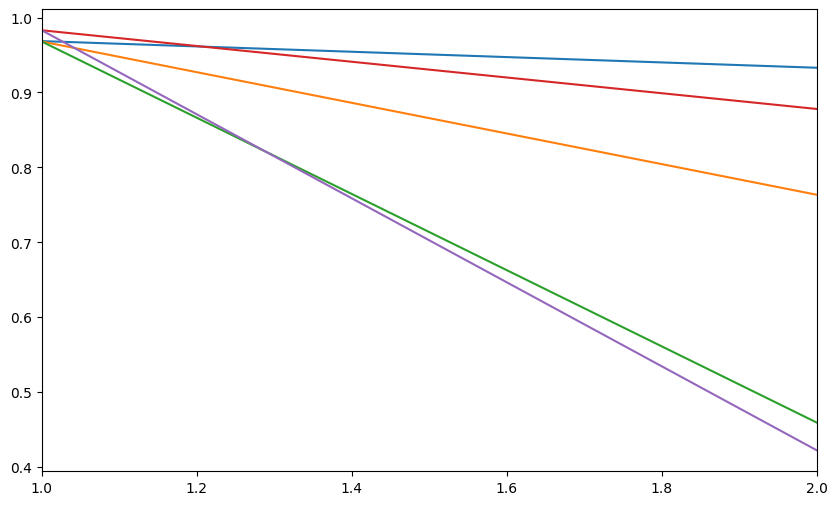

<Figure size 640x480 with 0 Axes>

In [66]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)

plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=avg['succeeded'],
    std=std['succeeded'],
    max_robots=max_robots,
    algs=algs,
    ylabel="Goal Success Rate",
)
fig.savefig('intersections_goal_success_rates.png', bbox_inches='tight')

Line2D(NAMO)
Line2D(NAMO w/o Deadlock Resolution)
Line2D(NAMO w/o Conflict Resolution)
Line2D(SNAMO)
Line2D(SNAMO w/o Conflict Resolution)


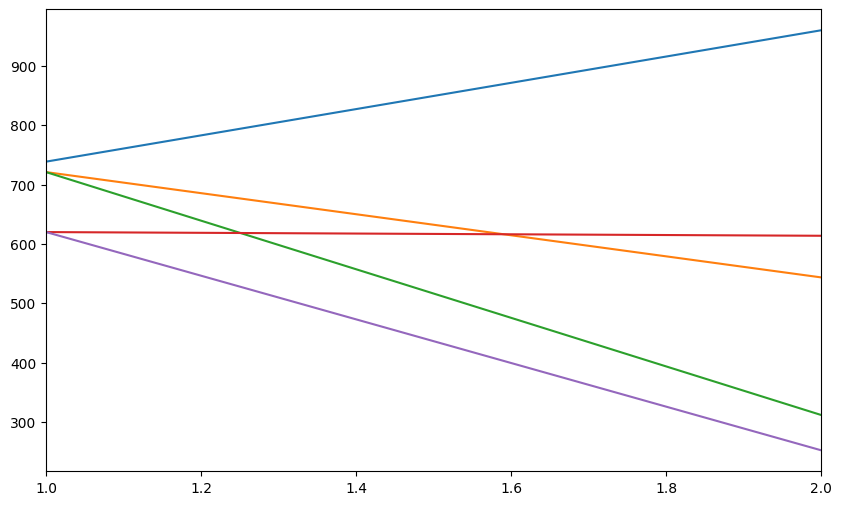

<Figure size 640x480 with 0 Axes>

In [67]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)

plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=avg['distance_traveled'],
    std=std['distance_traveled'],
    max_robots=max_robots,
    algs=algs,
    ylabel="Distance",
)
fig.savefig('intersections_avg_distance_traveled.png', bbox_inches='tight')

Line2D(NAMO)
Line2D(NAMO w/o Deadlock Resolution)
Line2D(NAMO w/o Conflict Resolution)
Line2D(SNAMO)
Line2D(SNAMO w/o Conflict Resolution)


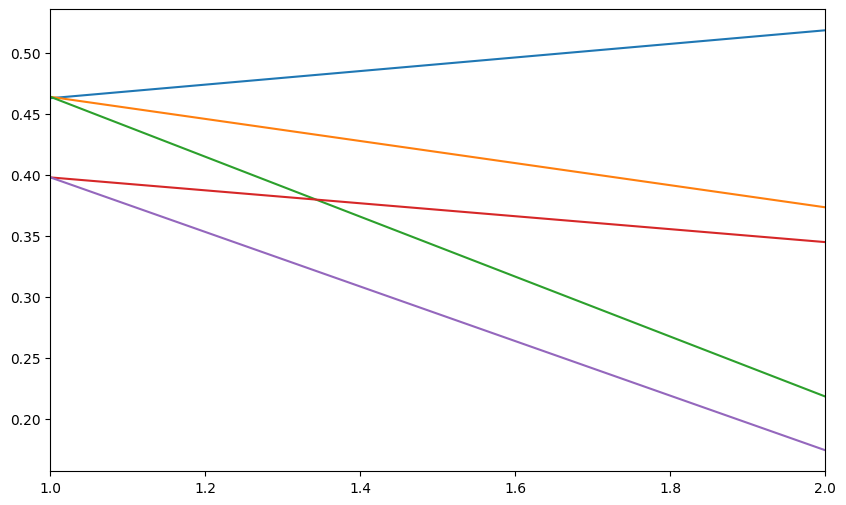

<Figure size 640x480 with 0 Axes>

In [68]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)
plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=avg['n_transfers'],
    std=std['n_transfers'],
    max_robots=max_robots,
    algs=algs,
    ylabel="Num Transfers",
)
fig.savefig('intersections_num_transfers.png', bbox_inches='tight')

Line2D(NAMO)
Line2D(NAMO w/o Deadlock Resolution)
Line2D(NAMO w/o Conflict Resolution)
Line2D(SNAMO)
Line2D(SNAMO w/o Conflict Resolution)


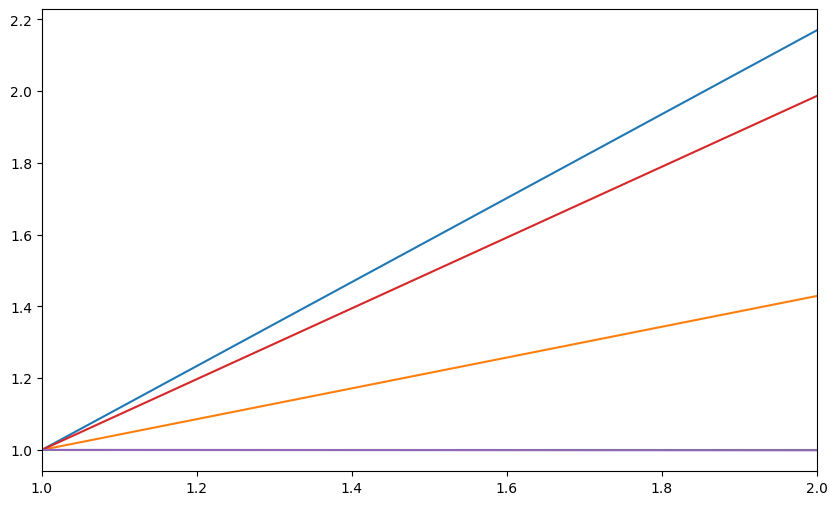

<Figure size 640x480 with 0 Axes>

In [69]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)
plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=avg['replans'],
    std=std['replans'],
    max_robots=max_robots,
    algs=algs,
    ylabel="Num Replans",
)
fig.savefig('intersections_num_replans.png', bbox_inches='tight')

Line2D(NAMO)
Line2D(NAMO w/o Deadlock Resolution)
Line2D(NAMO w/o Conflict Resolution)
Line2D(SNAMO)
Line2D(SNAMO w/o Conflict Resolution)


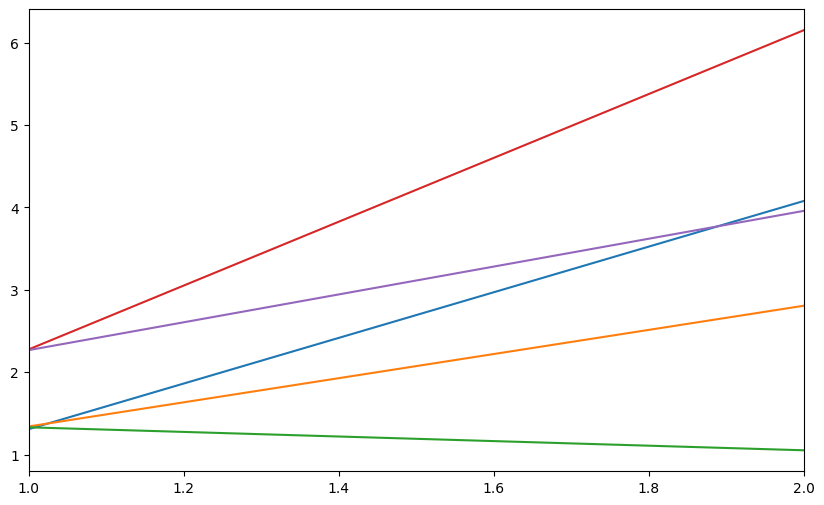

<Figure size 640x480 with 0 Axes>

In [70]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)
plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=avg['planning_time'],
    std=std['planning_time'],
    max_robots=max_robots,
    algs=algs,
    ylabel="Planning Time",
)
fig.savefig('intersections_planning_time.png', bbox_inches='tight')